In [335]:
!pip install -r requirements.txt

In [336]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

## Data Preprocessing

To prepare the [UAV Drone Dataset](https://www.kaggle.com/datasets/dasmehdixtr/drone-dataset-uav) for PCA, we transform raw images into a standardized mathematical matrix $X$.

### 1. Extraction (YOLO Parsing)
Each image has a `.txt` file with normalized coordinates ($x_{center}, y_{center}, w, h$). We use this data to **crop** the drone, removing background noise like trees or sky. 

### 2. Standardization
For PCA to function, all input vectors must have the same dimensionality:
* **Grayscale:** Reduces data from 3 channels (RGB) to 1.
* **Resizing:** Every crop is scaled to a uniform $64 \times 64$ size.
* **Flattening:** The $2D$ image matrix is unrolled into a $1D$ vector of $4096$ pixels ($n = 4096$). 

### 3. Normalization
Pixel values are scaled to $[0, 1]$ to ensure the variance in PCA is driven by the drone's structural features rather than lighting conditions. 

**Result:** A data matrix $X$ where each row is a cleaned, standardized drone signature.

In [337]:
def read_image(img_path):
    """Read image using CV library"""
    return cv2.imread(img_path)

def read_yolo_file(txt_path):
    """Read text yolo file"""
    with open(txt_path, 'r', encoding='utf-8') as f:
        drones = []
        
        for line in f:
            data = line.strip().split()
            if not data or len(data) < 5: 
                continue
            drone = {}
            drone['class_id'] = int(data[0])
            drone['x_center_norm'] = float(data[1])
            drone['y_center_norm'] = float(data[2])
            drone['width_norm'] = float(data[3])
            drone['height_norm'] = float(data[4])
            drones.append(drone)
    return drones

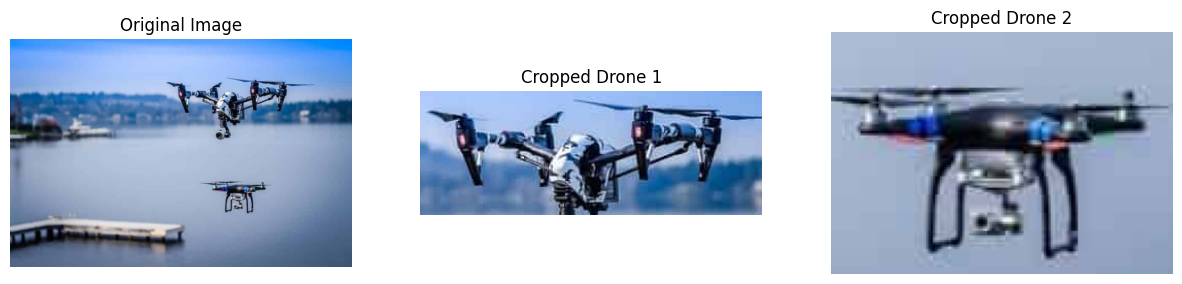

In [338]:
def crop_yolo_object(image, drones_yolo):
    """Croping the image using information from YOLO"""
    if image is None:
        return None
    
    if not drones_yolo:
        return None
    
    img_height, img_width = image.shape[:2]
    cropped_images = [] 
    
    for drone_yolo in drones_yolo:
        x_center = drone_yolo['x_center_norm'] * img_width
        y_center = drone_yolo['y_center_norm'] * img_height
        box_width = drone_yolo['width_norm'] * img_width
        box_height = drone_yolo['height_norm'] * img_height
        
        x1 = int(x_center - (box_width / 2))
        y1 = int(y_center - (box_height / 2))
        x2 = int(x_center + (box_width / 2))
        y2 = int(y_center + (box_height / 2))
        
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img_width, x2)
        y2 = min(img_height, y2)

        cropped_image = image[y1:y2, x1:x2]
        cropped_images.append(cropped_image)

    return cropped_images


def crop_drone(img_path, yolo_path):
    """Crop images to leave only drone"""
    img = read_image(img_path)
    drones_yolo = read_yolo_file(yolo_path)
    return crop_yolo_object(img, drones_yolo)
    
img_path = './archive/drone_dataset_yolo/dataset_txt/0010.jpg'
txt_path = './archive/drone_dataset_yolo/dataset_txt/0010.txt'

cropped_drones_list = crop_drone(img_path, txt_path) 
orig_img = read_image(img_path)

if cropped_drones_list is not None and orig_img is not None:
    orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    total_images = 1 + len(cropped_drones_list)
    fig, axes = plt.subplots(1, total_images, figsize=(5 * total_images, 5))
    
    if total_images == 2:
        axes = [axes[0], axes[1]]
    
    axes[0].imshow(orig_img_rgb)
    axes[0].axis('off')
    axes[0].set_title("Original Image")
    
    for i, cropped_img in enumerate(cropped_drones_list):
        img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)
        
        axes[i + 1].imshow(img_rgb)
        axes[i + 1].axis('off')
        axes[i + 1].set_title(f"Cropped Drone {i + 1}")
        
    plt.show()
else:
    print("Failed to process the image.")

### Load the Images

In [339]:
def flatten_image(image, target_size=(64, 64)):
    """Resize the image and flatten it"""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  
    image = cv2.resize(image, target_size)
    return image.flatten()

def create_drone_dataset(dataset_folder):
    """Create a dataset with all drones"""
    dataset_matrix = []
    
    for filename in os.listdir(dataset_folder):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            img_path = os.path.join(dataset_folder, filename)
            txt_path = img_path.rsplit('.', 1)[0] + '.txt' 
            
            if os.path.exists(txt_path):
                img = read_image(img_path)
                drones_yolo = read_yolo_file(txt_path)
                cropped_drones_list = crop_yolo_object(img, drones_yolo)
                
                if cropped_drones_list is not None:
                    for drone_img in cropped_drones_list:
                        flat_drone = flatten_image(drone_img, target_size=(64, 64))
                        dataset_matrix.append(flat_drone)

    X = np.array(dataset_matrix)
    return X

folder_path = './archive/drone_dataset_yolo/dataset_txt'
X = create_drone_dataset(folder_path)

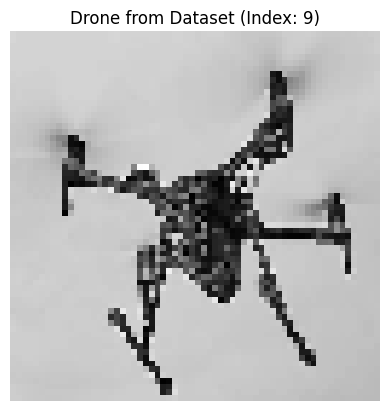

In [340]:
def show_drone_from_matrix(X, index=0, img_size=(64, 64)):
    """
    Displays a single image from the processed dataset matrix X.
    
    :param X: Dataset matrix (NumPy array)
    :param index: Index of the image to display (starting from 0)
    :param img_size: The target dimensions used during preprocessing (default 64x64)
    """
    # Check if the requested index exists in the matrix
    if index >= len(X):
        print(f"Error: The dataset contains only {len(X)} images. Index is out of bounds.")
        return

    # 1. Extract the specific row (vector) from the matrix
    flat_drone = X[index]

    # 2. Reshape the 1D vector (e.g., length 4096) 
    # back into a 2D image matrix (e.g., 64x64)
    drone_2d = flat_drone.reshape(img_size)

    # 3. Display the result using a grayscale colormap
    plt.imshow(drone_2d, cmap='gray')
    plt.title(f"Drone from Dataset (Index: {index})")
    plt.axis('off')
    plt.show()
show_drone_from_matrix(X, index=9)


Each image can be represented as a matrix of pixels. The RGB format involves a complex setup of three matrices representing the intensity of each color channel. To simplify calculations and improve efficiency, we convert the image to grayscale, which works effectively for the following algorithms.

For an image represented as an $N \times M$ matrix, we flatten it into an $NM \times 1$ vector to execute subsequent vector operations.

### Data Normalization

The next step for the PCA algorithm is data normalization. We define our data matrix $X$ as:

$$X = [x_1, x_2, x_3, \ldots, x_n] \tag{1}$$

where $x_i$ are the flattened image vectors from our dataset.

### Mean Vector

We then calculate the mean vector:

$$\mu = \frac{1}{n} \sum_{i=1}^{n} x_i \tag{2}$$

In [341]:
def calculate_mean_vector(X):
    mean_vector = np.mean(X, axis=0)
    return mean_vector

X_mean = calculate_mean_vector(X)
print(X)
print(X_mean)

[[219 221 221 ... 212 211 211]
 [208 208 208 ... 216 216 216]
 [233 233 234 ... 222 222 222]
 ...
 [ 40  42  48 ... 135 131 143]
 [159 158 158 ...  47  59  65]
 [172 169 172 ... 143 145 150]]
[180.38156124 180.7039031  181.3640646  ... 178.54912517 178.75235532
 179.3526245 ]


### Centralized Data

The centralized data of the set is then represented as:

$$\bar{x}_i = x_i - \mu \tag{3}$$

In [342]:
def centralize_data(X, mean_vector):
    X_centered = X - mean_vector
    return X_centered

X_centered = centralize_data(X, X_mean)
print(X_centered)

[[  38.61843876   40.2960969    39.6359354  ...   33.45087483
    32.24764468   31.6473755 ]
 [  27.61843876   27.2960969    26.6359354  ...   37.45087483
    37.24764468   36.6473755 ]
 [  52.61843876   52.2960969    52.6359354  ...   43.45087483
    43.24764468   42.6473755 ]
 ...
 [-140.38156124 -138.7039031  -133.3640646  ...  -43.54912517
   -47.75235532  -36.3526245 ]
 [ -21.38156124  -22.7039031   -23.3640646  ... -131.54912517
  -119.75235532 -114.3526245 ]
 [  -8.38156124  -11.7039031    -9.3640646  ...  -35.54912517
   -33.75235532  -29.3526245 ]]


### Covariance Matrix

The following step involves calculating the covariance matrix using the formula:

$$C = \frac{1}{n} \bar{X} \bar{X}^T \tag{4}$$

To optimize calculation for high-resolution images, we use a mathematical trick by defining a smaller matrix $C'$:

$$C' = \bar{X}^T \bar{X} \tag{5}$$

This allows us to process datasets where the number of images is much smaller than the number of pixels.

In [343]:
def calculate_covariance_matrix(X):
    # Center the data
    X_centered = centralize_data(X, calculate_mean_vector(X))
    # Calculate the covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False)

    return covariance_matrix

print(calculate_covariance_matrix(X))

[[5417.96542409 5268.89689357 5116.70678476 ... 3655.77821281
  3685.20835996 3681.58388007]
 [5268.89689357 5374.78499486 5194.22436931 ... 3603.86573406
  3626.46534434 3635.60145103]
 [5116.70678476 5194.22436931 5281.61080205 ... 3592.58041972
  3593.82422611 3589.77658596]
 ...
 [3655.77821281 3603.86573406 3592.58041972 ... 5325.58378038
  5204.21958119 5010.92340634]
 [3685.20835996 3626.46534434 3593.82422611 ... 5204.21958119
  5324.75344563 5126.39176149]
 [3681.58388007 3635.60145103 3589.77658596 ... 5010.92340634
  5126.39176149 5232.11530287]]


## Eigenvectors and Eigenvalues

To proceed, we must utilize Eigenvectors and Eigenvalues. By definition, the transformation of an eigenvector $v$ by a matrix $A$ is:

$$Av = \lambda v \tag{6}$$

where $\lambda$ represents the eigenvalue.

Assuming $C' = \bar{X}^T \bar{X}$ is our $A$:

$$(\bar{X}^T \bar{X}) v = \lambda v \tag{7}$$

Left-multiplying by $\bar{X}$:

$$(\bar{X} \bar{X}^T)(\bar{X} v) = \lambda (\bar{X} v) \tag{8}$$

This proves that $(\bar{X} v)$ is the eigenvector of the large covariance matrix $C$.

In [344]:
def qr_eigen(A, max_iterations=20, tol=1e-5):
    A_k = np.copy(A).astype(float)
    n = A.shape[0]
    qq = np.eye(n) 

    for i in range(max_iterations):
        q, r = np.linalg.qr(A_k)
        A_k = r @ q
        qq = qq @ q

        # Early Stopping
        off_diagonal = np.linalg.norm(np.tril(A_k, -1))
        if off_diagonal < tol:
            break
            
    return np.diag(A_k), qq


def fast_pca_algorithm(X):
    X_mean = calculate_mean_vector(X)
    X_centered = centralize_data(X, X_mean)
    
    # Gram matrix trick
    K = (X_centered @ X_centered.T) / (X.shape[0] - 1)
    
    evals, v_small = qr_eigen(K)
    
    # sorting the results (important for PCA)
    idx = evals.argsort()[::-1]
    evals = evals[idx]
    v_small = v_small[:, idx]
    
    # Turning small eigenvectors into eigenvectors of the large covariance matrix
    # V_large = X^T * V_small
    eigenvectors_large = X_centered.T @ v_small
    
    # Vectors Normalization: normalizing the eigenvectors to unit length
    for i in range(eigenvectors_large.shape[1]):
        norm = np.linalg.norm(eigenvectors_large[:, i])
        if norm > 1e-15:
            eigenvectors_large[:, i] /= norm
            
    return evals, eigenvectors_large


evals, evecs = fast_pca_algorithm(X)

print(f"Eigenvalues quantity: {len(evals)}")
print(f"Shape of eigenvectors matrix: {evecs.shape}")
print("First 3 eigenvalues:", evals[:3])

print(fast_pca_algorithm(X))

Eigenvalues quantity: 1486
Shape of eigenvectors matrix: (4096, 1486)
First 3 eigenvalues: [8857398.48898217 1581405.44327752  647416.2100681 ]
(array([8.85739849e+06, 1.58140544e+06, 6.47416210e+05, ...,
       1.21179962e+00, 8.25238736e-01, 2.45496834e-11], shape=(1486,)), array([[ 0.02022459, -0.01572823,  0.01701357, ..., -0.00456982,
         0.00371652,  0.0075064 ],
       [ 0.01996169, -0.01590833,  0.0173193 , ...,  0.01706265,
         0.00368691,  0.01782008],
       [ 0.01997543, -0.01550813,  0.01686687, ...,  0.00978159,
         0.01292773,  0.02251921],
       ...,
       [ 0.01965415, -0.01441002, -0.00804448, ...,  0.00653673,
        -0.0087181 ,  0.00170877],
       [ 0.01970574, -0.01470974, -0.00841173, ...,  0.00085225,
         0.00274705,  0.00378372],
       [ 0.01952796, -0.01514972, -0.00774324, ..., -0.00239653,
        -0.0065997 ,  0.01452459]], shape=(4096, 1486)))


## Power Method and Projection

We use the power method to find the dominant eigenvector:

$$x_{k+1} = \frac{A x_k}{\| A x_k \|} \tag{9}$$

This iterates until convergence. We then build matrix $Y$ (the "eigendrone" space) and project our data:

$$Z = Y^T \bar{X} \tag{10}$$

For a test image $x_{\text{test}}$, we center and project it:

$$Z_{\text{test}} = Y^T (x_{\text{test}} - \mu) \tag{11}$$

Finally, we calculate the Euclidean distance between projections. If the distance is below an experimental threshold, the object is classified as a drone.

In [ ]:
def power_method(C, epsilon=1e-6, max_iter=1000):
    n = C.shape[0]
    evec = np.random.rand(n) # getting random vector
    evec = evec / np.linalg.norm(evec) # normalizing

    for _ in range(max_iter):
        new_evec = C @ evec
        b_new_norm = np.linalg.norm(new_evec) 

        if b_new_norm == 0:
            return evec, 0

        new_evec = new_evec / b_new_norm

        # Correcting for "sign flipping" of the vector
        # We use the dot product. If the vectors are parallel 
        # even if they point in opposite directions, the absolute value of their dot product will be 1.0
        if 1.0 - np.abs(np.dot(new_evec, evec)) < epsilon:
            break

        evec = new_evec

    # Calculate the eigenvalue (Rayleigh quotient)
    eigenvalue = np.dot(evec.T, np.dot(C, evec))
    return evec, eigenvalue


def power_method_pca(covariance_matrix, variance_threshold=0.95):
    C = covariance_matrix.copy()
    
    # Total variance is the sum of eigenvalues, which is also the trace of the covariance matrix (sum of diagonal elements)
    total_variance = np.trace(C) 

    eigenvectors = []
    eigenvalues = []
    explained_variance = 0.0

    while explained_variance < variance_threshold:
        v, e = power_method(C)

        # If the eigenvalue is too small (noise), we stop
        if e <= 1e-5: 
            break

        # Correcting for numerical instability: orthogonalization step (Gram-Schmidt process)
        # We clean the new vector from any remnants of previous vectors that may have appeared due to floating-point errors.
        for prev_v in eigenvectors:
            v = v - np.dot(v, prev_v) * prev_v
        
        # Normalize again after orthogonalization
        v_norm = np.linalg.norm(v)
        if v_norm > 0:
            v = v / v_norm

        eigenvectors.append(v)
        eigenvalues.append(e)

        explained_variance = sum(eigenvalues) / total_variance

        # Deflation: removing the projection of this vector from the matrix
        C = C - e * np.outer(v, v) 

    # Turn the list of eigenvectors into a matrix. Transpose (.T) to have eigenvectors as COLUMNS, as is standard in mathematics
    return np.array(eigenvectors).T, np.array(eigenvalues)
# 1. First, we center our data (subtract the mean drone)
mean_vector = np.mean(X, axis=0)
X_centered = X - mean_vector



N = X_centered.shape[0]


# Using the Gram matrix trick to compute eigenvectors of the covariance matrix
K = (X_centered @ X_centered.T) / (N - 1)
v_small, evals_1 = power_method_pca(K)

# Turning small eigenvectors into eigenvectors of the large covariance matrix
evecs_1 = X_centered.T @ v_small

evecs_1 = evecs_1 / np.linalg.norm(evecs_1, axis=0)


print(f"Eigenvalues quantity: {len(evals_1)}")
print(f"Shape of the eigenvector matrix: {evecs_1.shape}") # Should be (4096, 220)

Кількість власних значень: 203
Розмірність матриці векторів: (4096, 203)


In [353]:
print(evals_1[:3])
print(N)
print(X_centered.shape, X_centered.T.shape)
print(K.shape)
C_1 = X_centered @ X_centered.T / (N - 1)
print(C_1.shape)

[8857382.79791677 1581489.07733545  647429.13304609]
1486
(1486, 4096) (4096, 1486)
(1486, 1486)
(1486, 1486)


### Testing

In [ ]:
def z_test(X_test, mean_vector, eigenvectors):
    """
    Projects new images (X_test) into the PCA space.
    X_test can be either a single image (1D vector) or a matrix of multiple
    """
    # We subtract the mean drone from the new images to center them in the same way as our training data.
    X_centered = X_test - mean_vector
    
    # Project the data (compress)
    projections = np.dot(X_centered, eigenvectors)
    return projections

In [ ]:
def calculate_euclidean_distance(projections, threshold):
    """
    Calculate the distance from the projected images to the 'ideal average drone' (zero in PCA).
    """
    # If we passed a single image (1D vector), we reshape it into a 2D matrix with 1 row
    if projections.ndim == 1:
        projections = projections.reshape(1, -1)
        
    # Calculate the Euclidean distance for each row
    distances = np.linalg.norm(projections, axis=1)

    # Return both the distances and the decision (True/False)
    is_drone = distances < threshold
    
    return distances, is_drone

In [ ]:
# 1. First, we project our entire training dataset (matrix X) into the PCA space.
Z_train = z_test(X, mean_vector, evecs_1)

# 2. We calculate the distances for all training drones
# (we set the threshold to infinity here because we only need the distance numbers)

# 2. We calculate the distances for all training drones
# (we set the threshold to infinity here because we only need the distance numbers)
train_distances, _ = calculate_euclidean_distance(Z_train, threshold=float('inf'))

# 3. We analyze the distances of the real drones
mean_dist = np.mean(train_distances)
max_dist = np.max(train_distances)

print(f"Mean distance for real drones: {mean_dist:.2f}")
print(f"Maximum distance for real drones: {max_dist:.2f}")

# We set the threshold slightly above the mean (or take the maximum)
MY_THRESHOLD = mean_dist + np.std(train_distances)
print(f"Our chosen threshold for testing: {MY_THRESHOLD:.2f}")

Середня відстань для справжніх дронів: 4296.91
Максимальна відстань для справжніх дронів: 9507.68
Наш обраний поріг для тестування: 5583.07


In [ ]:
# Assuming you have some new image test_image (numpy array)
# 1. We do the same preprocessing for it as for the training data
# (convert to grayscale, resize to 64x64, and flatten)
test_image1 = read_image('./example-test.jpg')
test_flat1 = flatten_image(test_image1, target_size=(64, 64))
test_image = read_image('./image_1.png')
test_flat = flatten_image(test_image, target_size=(64, 64))

# 2. We get the projection using your function
test_projection = z_test(test_flat, mean_vector, evecs_1)

# 3. We check if it's a drone
distances, is_drone_array = calculate_euclidean_distance(test_projection, MY_THRESHOLD)

# Since we passed a single image, we take the 0th element
dist = distances[0]
is_drone = is_drone_array[0]

if is_drone:
    print(f"✅ This is a DRONE! (Distance: {dist:.2f} < Threshold: {MY_THRESHOLD:.2f})")
else:
    print(f"❌ This is NOT a drone. (Distance: {dist:.2f} > Threshold: {MY_THRESHOLD:.2f})")

✅ Це ДРОН! (Відстань: 5521.40 < Поріг: 5583.07)


In [ ]:
def check_is_drone_no_background(test_flat, mean_vector, eigenvectors, drop_first_k=5):
    # 1. Centering
    centered_img = test_flat - mean_vector
    
    # 2. We discard the first K vectors (which represent background and lighting)
    # We take all rows, but start columns from drop_first_k
    evecs_details = eigenvectors[:, drop_first_k:]
    
    # 3. We project and reconstruct ONLY on the "detail" vectors
    weights = np.dot(centered_img, evecs_details)
    reconstructed_img = np.dot(weights, evecs_details.T)
    
    # 4. We calculate the relative error
    abs_error = np.linalg.norm(centered_img - reconstructed_img)
    img_complexity = np.linalg.norm(centered_img)
    
    if img_complexity == 0:
        return 0.0
        
    relative_error = abs_error / img_complexity
    
    return relative_error

error_sky = check_is_drone_no_background(test_flat, mean_vector, evecs_1)
error_real_drone = check_is_drone_no_background(test_flat1, mean_vector, evecs_1)

# We use your projection function
proj_sky = z_test(test_flat, mean_vector, evecs_1)
proj_drone = z_test(test_flat1, mean_vector, evecs_1)

# We calculate the distance to the "Average drone" (zero in PCA)
dist_sky = np.linalg.norm(proj_sky)
dist_drone = np.linalg.norm(proj_drone)

print(f"YOUR APPROACH - Sky distance: {dist_sky}")
print(f"YOUR APPROACH - Drone distance: {dist_drone}")

print(f"Sky error: {error_sky}")
print(f"Drone error: {error_real_drone}")

ТВІЙ ПІДХІД - Відстань неба: 5521.395213099743
ТВІЙ ПІДХІД - Відстань дрона: 3425.8009809875025
Помилка неба: 0.959599531942445
Помилка дрона: 0.772848042550078


Шукаю дрона...
✅ Дрона знайдено! Відстань: 1957.52 (Поріг: 2000)


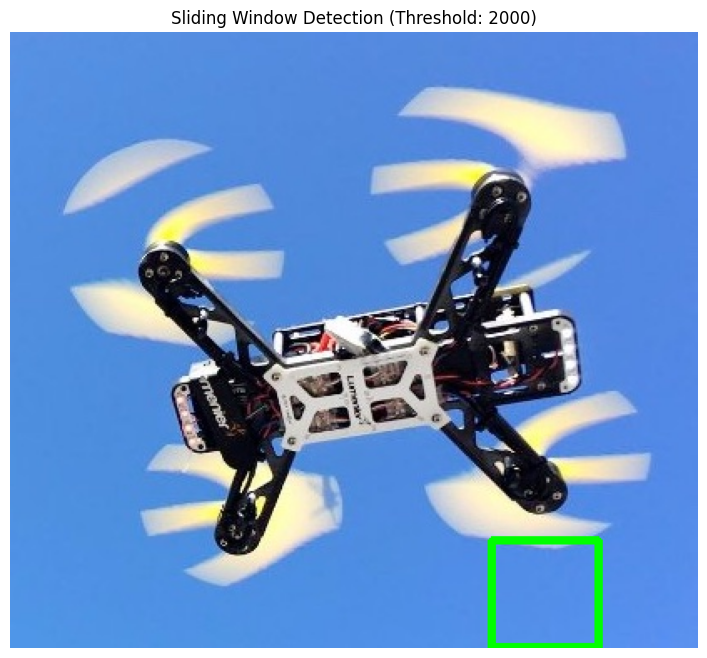

In [ ]:
import cv2
import matplotlib.pyplot as plt

def detect_drone_sliding_window(large_image_path, mean_vector, eigenvectors, threshold=3600, window_size=(64, 64), step_size=16):
    # 1. We load the large image
    img = cv2.imread(large_image_path)
    if img is None:
        print("Error: Image not found!")
        return
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # For nice display
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # For mathematics
    
    best_dist = float('inf')
    best_box = None
    
    print("Searching for drone...")
    
    # 2. "Sliding" the window over height and width
    for y in range(0, img_gray.shape[0] - window_size[1], step_size):
        for x in range(0, img_gray.shape[1] - window_size[0], step_size):
            
            # Extract the current window
            window = img_gray[y:y + window_size[1], x:x + window_size[0]]
            
            # Flatten (and normalize if you divided by 255 during training)
            # If you didn't divide by 255.0 in the dataset, remove this division here!
            window_flat = window.flatten() # / 255.0 
            
            # 3. WE USE YOUR FUNCTIONS:
            test_projection = z_test(window_flat, mean_vector, eigenvectors)
            
            # If you remember, test_projection might be 1D, so we reshape
            if test_projection.ndim == 1:
                test_projection = test_projection.reshape(1, -1)
                
            dist = np.linalg.norm(test_projection, axis=1)[0]
            
            # 4. We look for the smallest distance that is below the threshold
            if dist < threshold and dist < best_dist:
                best_dist = dist
                best_box = (x, y, window_size[0], window_size[1])
                
    # 5. Draw the result
    result_img = img_rgb.copy()
    if best_box is not None:
        x, y, w, h = best_box
        # Draw a green rectangle around the detected drone
        cv2.rectangle(result_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
        print(f"✅ Drone detected! Distance: {best_dist:.2f} (Threshold: {threshold})")
    else:
        print(f"❌ No drones found in the image (All distances > {threshold}).")
        
    plt.figure(figsize=(10, 8))
    plt.imshow(result_img)
    plt.axis('off')
    plt.title(f"Sliding Window Detection (Threshold: {threshold})")
    plt.show()

# --- How to run ---
# Find a large drone image from the dataset (not txt, but jpg) and test it!
test_large_img_path = './archive/drone_dataset_yolo/dataset_txt/0015.jpg'
detect_drone_sliding_window(test_large_img_path, mean_vector, evecs_1, threshold=2000)